In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pynumdiff
from copy import copy
import scipy

2026-03-23 15:24:14,708 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2026-03-23 15:24:14,710 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2026-03-23 15:24:14,710 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



In [2]:
SNR=20

## AGROS test SNR

In [3]:
true_matrix_a = np.array([1, -1, -1, 1])
def f(x, t, a):
    return [
        (a[0] * x[0]) + (a[1] * (x[0] * x[1])),
        (a[2] * x[1]) + (a[3] * (x[0] * x[1])),
    ]

def lotka_volterra_ode(n, dt, init_conditions, snr):
    t_span = np.arange(0, float(n)*dt, dt) 
    x_total = odeint(f, init_conditions, t_span, args=(true_matrix_a,)) # noiseless data
    if snr != 0:
        eps = 10 ** -(snr / 20)
        x_init = x_total.copy()
        for i in range(int(x_total.shape[1])):
            x_total[:,i] = x_total[:, i] + eps * np.random.normal(scale=np.std(x_init[:,i]), size=x_init[:,i].shape)
    
    return(x_total)

In [4]:
def save_SNR_instance(name,SNR,x,y):
    for i in range(0,3):
        x_n=x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(x), size=len(x))
        y_n=y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(y), size=len(y))

        plt.plot(t,x_n)
        plt.plot(t,y_n)
        plt.title(f'SNR: {SNR}, instance: {i}')
        plt.show()
        
        data = pd.DataFrame(data={'t':t, 'x':x_n, 'y':y_n})
        data.to_csv(f'datasets/{name}_SNR_{SNR}_{i}.csv')

## Bacterial Respiration

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  2.980e+01  2.990e+01]
        y: [[ 9.015e+00  9.800e+00 ...  9.797e+00  9.800e+00]
            [ 1.280e+01  1.353e+01 ...  5.088e+01  5.086e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 86
     njev: 0
      nlu: 0
300


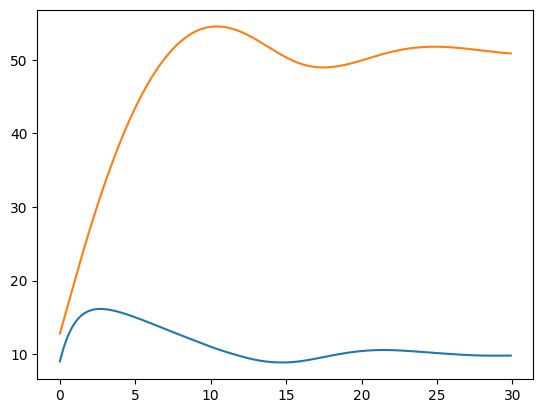

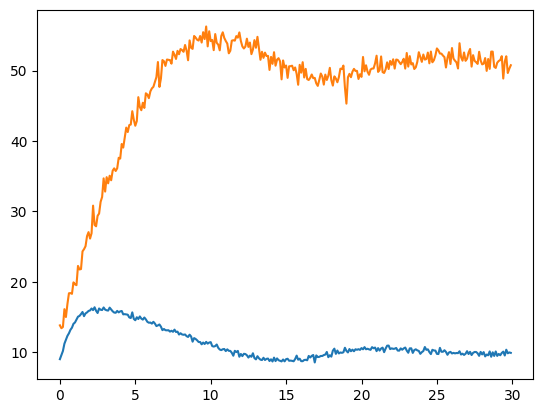

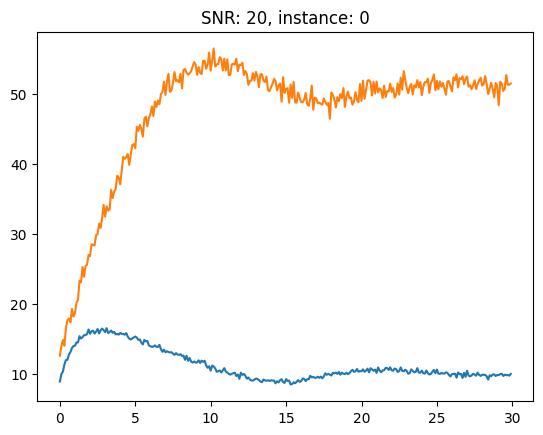

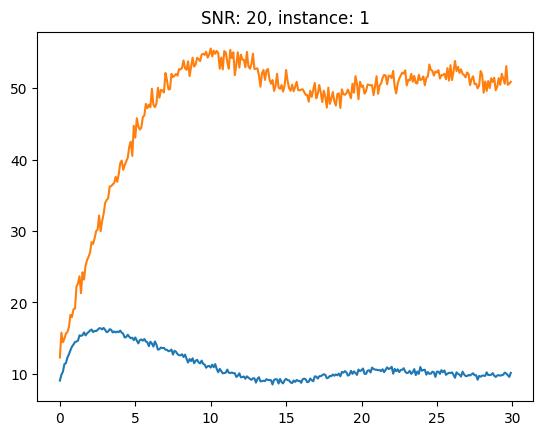

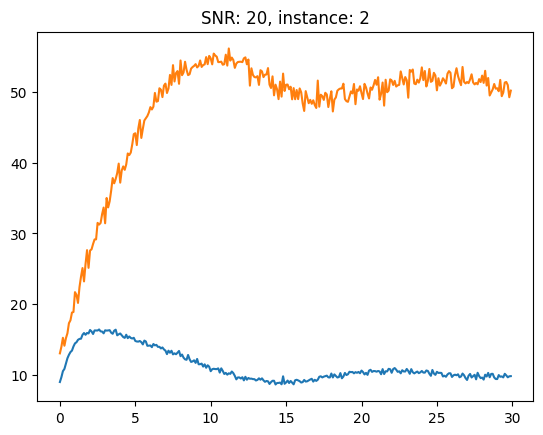

In [5]:
def dx(x,y):
    return 20. - x - x *y/(1+0.5 * x*x)
def dy(x,y):
    return 10 - x * y / (1+0.5 * x*x)

h=0.1
t= np.arange(0,30,h)

def ode(t,y):
    return [dx(*y),dy(*y)]
sol=scipy.integrate.solve_ivp(ode, [t[0],t[-1]], y0=[9.015,12.8015], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]
    
print(len(t))
plt.plot(t,t_x)
plt.plot(t,t_y)
plt.show()
t_x_n=t_x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_x), size=len(t_x))
t_y_n=t_y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_y), size=len(t_x))

plt.plot(t,t_x_n)
plt.plot(t,t_y_n)
plt.show()

save_SNR_instance('bact_res',SNR,t_x,t_y)

## Bar Magnets

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  1.480e+01  1.490e+01]
        y: [[ 4.265e+00  4.331e+00 ...  6.033e+00  6.034e+00]
            [ 4.761e+00  4.885e+00 ...  6.533e+00  6.532e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 50
     njev: 0
      nlu: 0
150


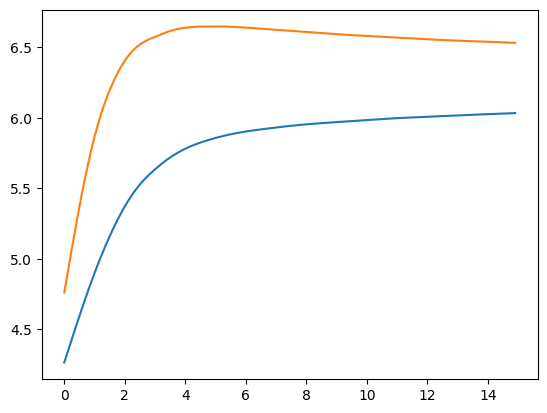

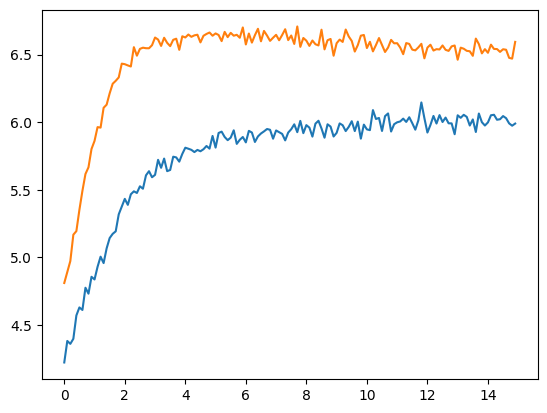

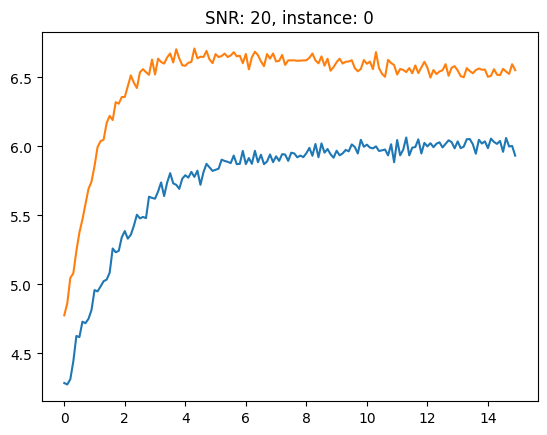

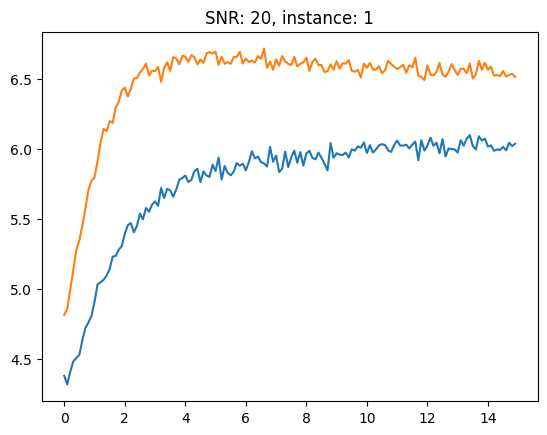

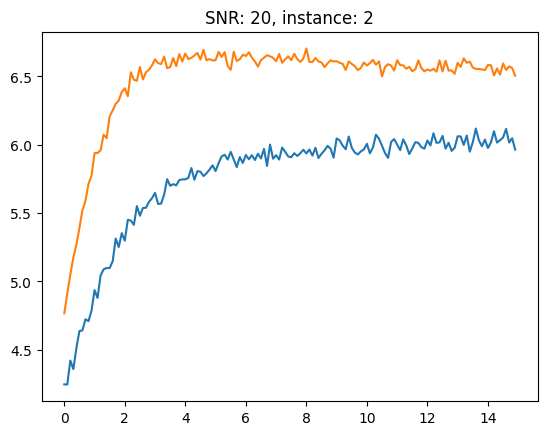

In [6]:
def dx(x,y):
    return 0.5*np.sin(x-y) - np.sin(x)
def dy(x,y):
    return 0.5*np.sin(y-x) - np.sin(y)

h=0.1
t= np.arange(0,15,h)

def ode(t,y):
    return [dx(*y),dy(*y)]
sol=scipy.integrate.solve_ivp(ode, [t[0],t[-1]], y0=[4.2646,4.76102], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]
    
print(len(t))
plt.plot(t,t_x)
plt.plot(t,t_y)
plt.show()

t_x_n=t_x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_x), size=len(t_x))
t_y_n=t_y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_y), size=len(t_x))

plt.plot(t,t_x_n)
plt.plot(t,t_y_n)
plt.show()

save_SNR_instance('bar_mag',SNR,t_x,t_y)

## Glider

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  1.980e+01  1.990e+01]
        y: [[ 5.603e+00  5.370e+00 ...  1.316e+00  1.372e+00]
            [ 1.855e+00  2.413e+00 ...  3.696e+01  3.704e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 236
     njev: 0
      nlu: 0
200


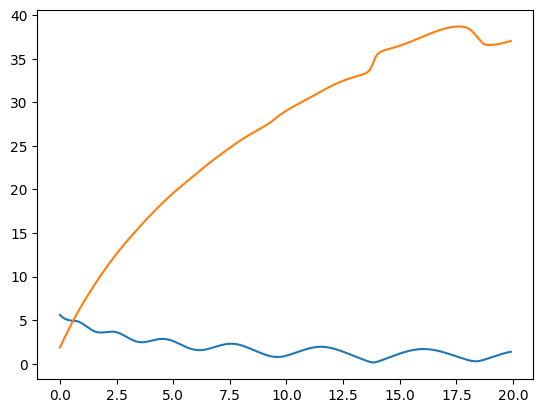

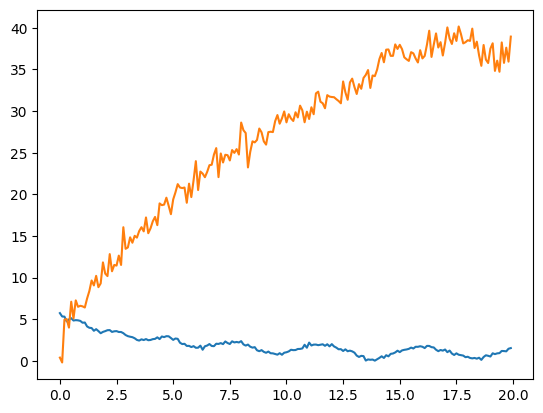

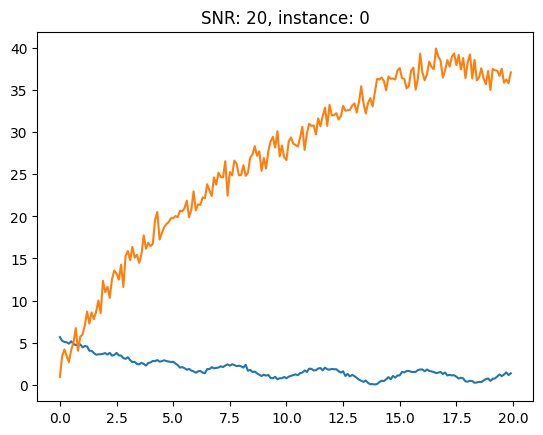

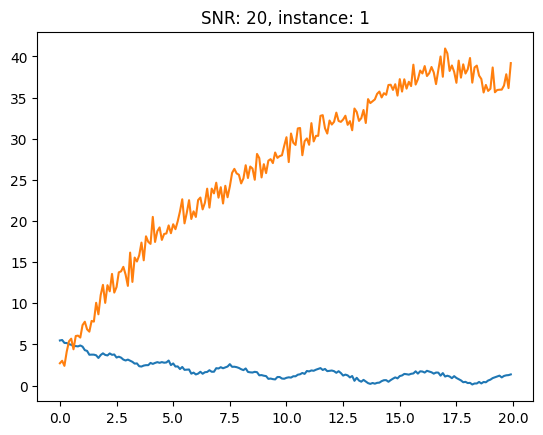

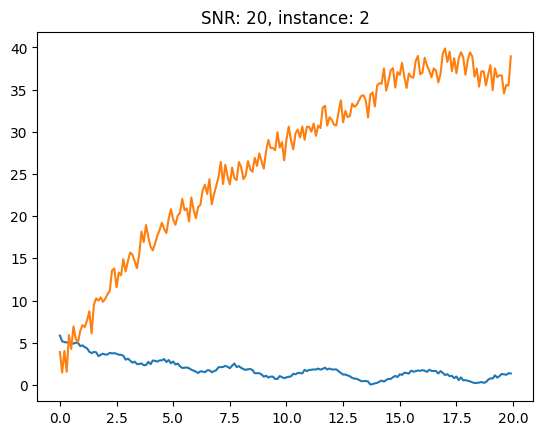

In [7]:
def dx(x,y):
    return -0.05 * x*x - np.sin(y)
def dy(x,y):
    return x - np.cos(y)/x

h=0.1
t= np.arange(0,20,h)

def ode(t,y):
    return [dx(*y),dy(*y)]
sol=scipy.integrate.solve_ivp(ode, [t[0],t[-1]], y0=[5.60327,1.85512], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]
    
print(len(t))
plt.plot(t,t_x)
plt.plot(t,t_y)
plt.show()
t_x_n=t_x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_x), size=len(t_x))
t_y_n=t_y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_y), size=len(t_x))

plt.plot(t,t_x_n)
plt.plot(t,t_y_n)
plt.show()

save_SNR_instance('glider',SNR,t_x,t_y)

## Lotka-Volterra

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  9.800e+00  9.900e+00]
        y: [[ 1.000e+00  7.146e-01 ...  4.797e-05  4.341e-05]
            [ 3.000e+00  2.557e+00 ...  2.000e+00  2.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0
100


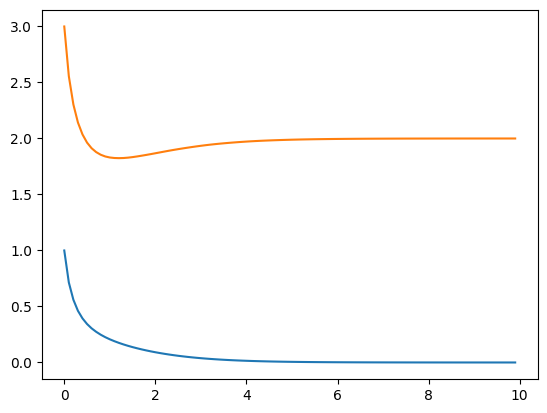

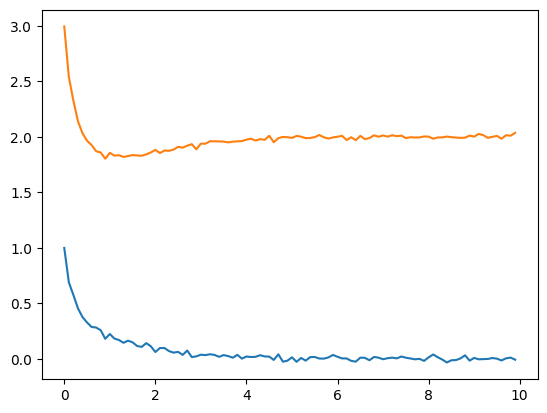

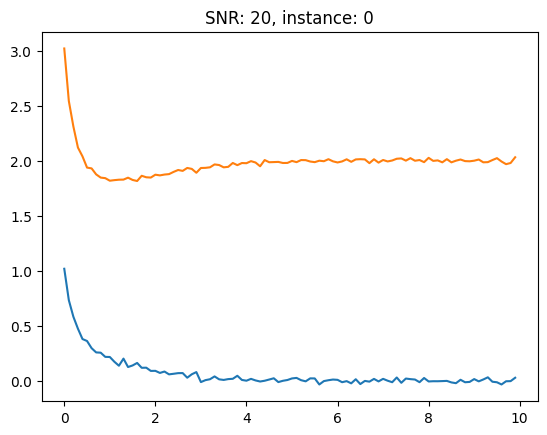

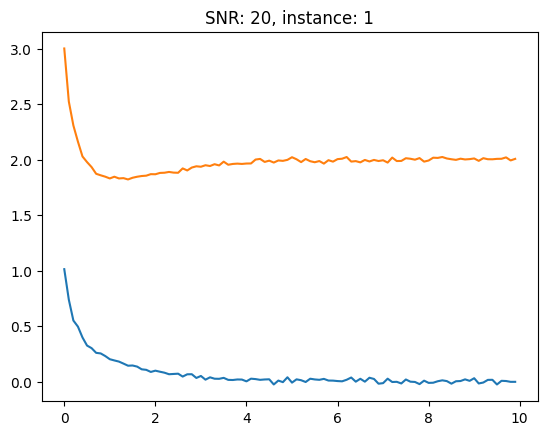

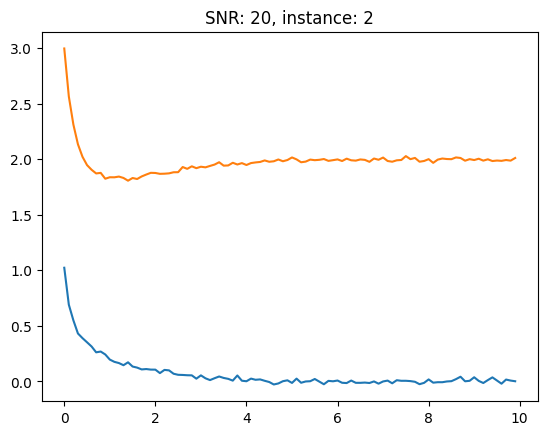

In [8]:
def dx(x,y):
    return 3*x - 2*x*y - x*x
def dy(x,y):
    return 2*y-x*y-y*y

h=0.1
t= np.arange(0,10,h)

def ode(t,y):
    return [dx(*y),dy(*y)]
sol=scipy.integrate.solve_ivp(ode, [t[0],t[-1]], y0=[1.,3.], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]
    
print(len(t))
plt.plot(t,t_x)
plt.plot(t,t_y)
plt.show()
t_x_n=t_x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_x), size=len(t_x))
t_y_n=t_y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_y), size=len(t_x))

plt.plot(t,t_x_n)
plt.plot(t,t_y_n)
plt.show()

save_SNR_instance('lotka_volterra',SNR,t_x,t_y)

## Predator - Prey

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  1.480e+01  1.490e+01]
        y: [[ 4.861e+00  3.797e+00 ...  1.936e-01  2.088e-01]
            [ 1.151e+01  1.145e+01 ...  3.677e+00  3.638e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 146
     njev: 0
      nlu: 0
150


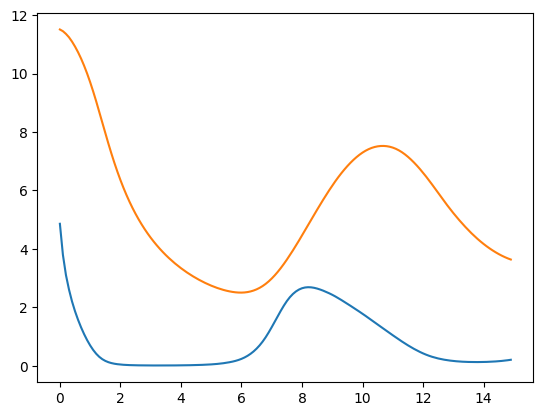

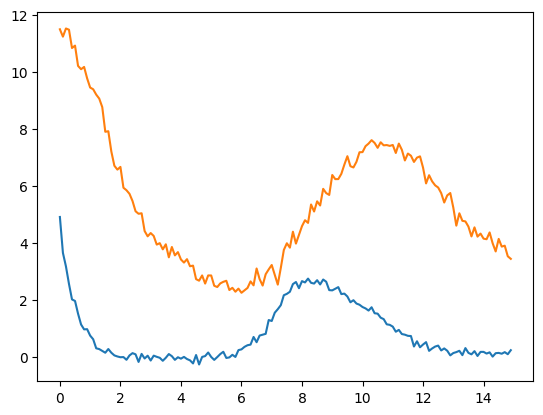

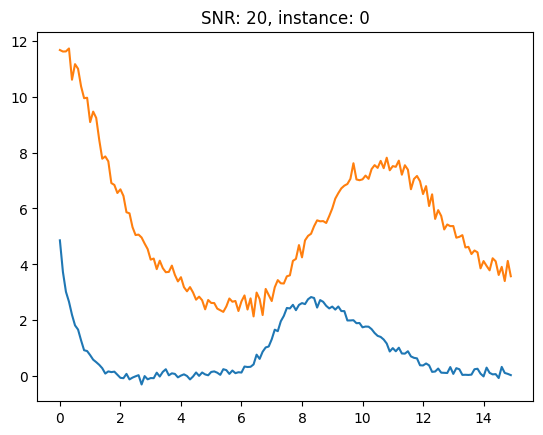

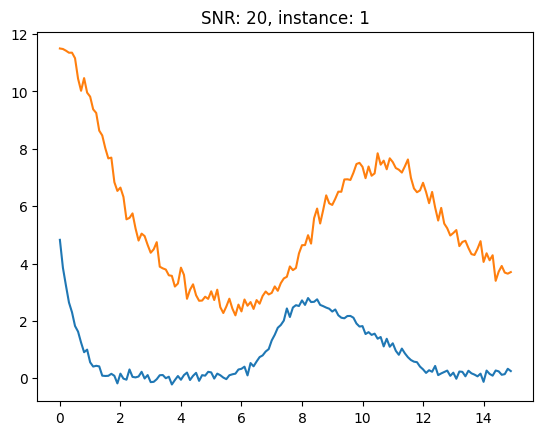

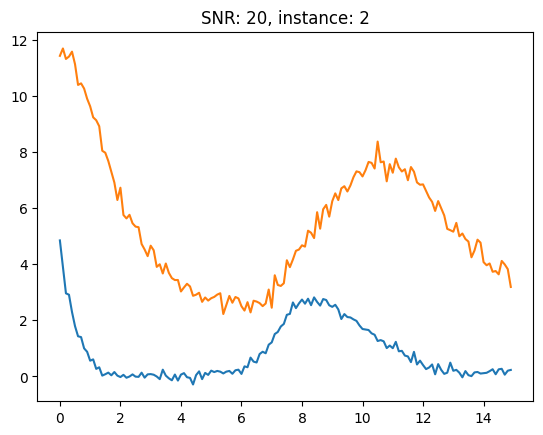

In [9]:
def dx(x,y):
    return x * (4. - x - y/(1+x))
def dy(x,y):
    return y * (x /(1+x) - 0.075 * y)

h=0.1
t= np.arange(0,15,h)

def ode(t,y):
    return [dx(*y),dy(*y)]
sol=scipy.integrate.solve_ivp(ode, [t[0],t[-1]], y0=[4.8607,11.5069], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]
    
print(len(t))
plt.plot(t,t_x)
plt.plot(t,t_y)
plt.show()
t_x_n=t_x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_x), size=len(t_x))
t_y_n=t_y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_y), size=len(t_x))

plt.plot(t,t_x_n)
plt.plot(t,t_y_n)
plt.show()

save_SNR_instance('pred_prey',SNR,t_x,t_y)

## Shear Flow

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  1.980e+01  1.990e+01]
        y: [[-1.402e+00 -1.404e+00 ... -1.384e+00 -1.386e+00]
            [-1.426e+00 -1.437e+00 ... -1.408e+00 -1.420e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 134
     njev: 0
      nlu: 0
200


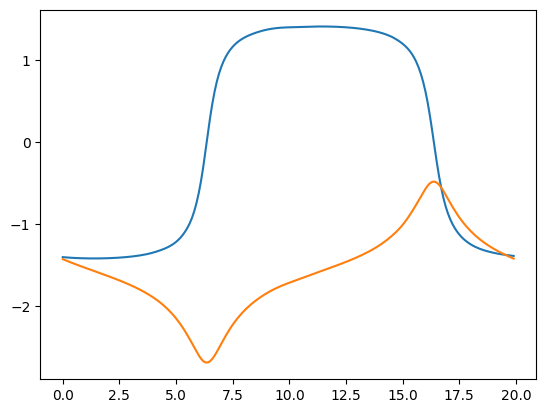

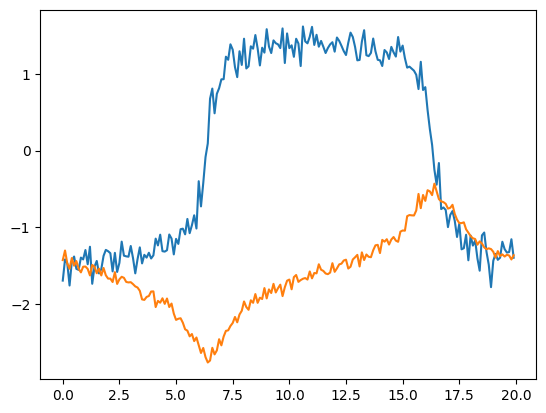

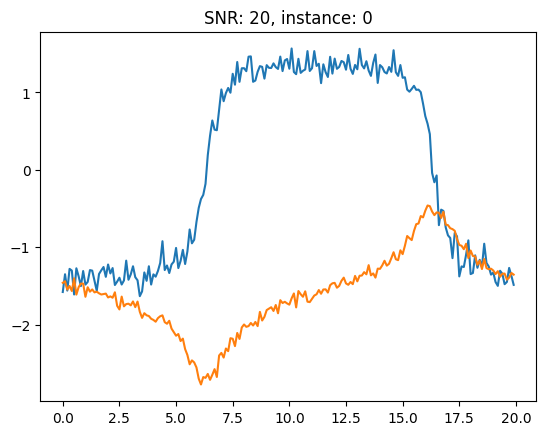

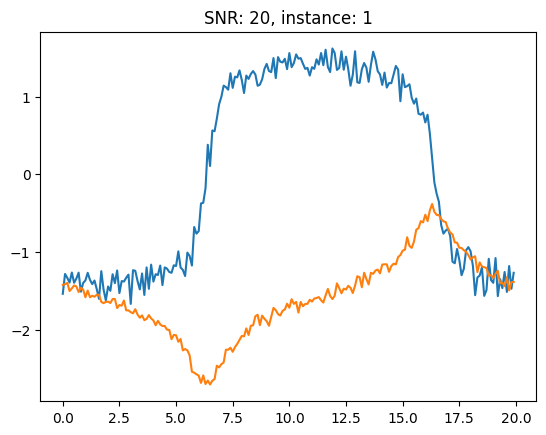

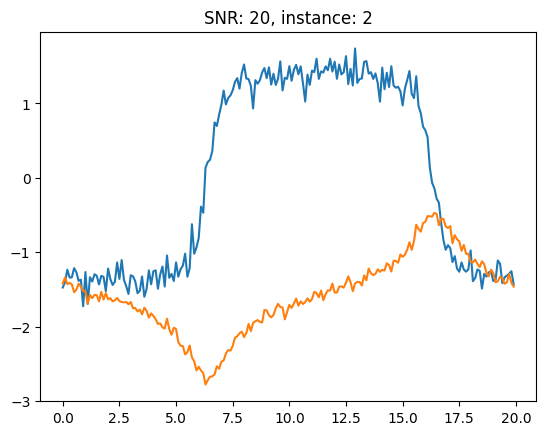

In [10]:
def dx(x,y):
    return 1./np.tan(y) * np.cos(x)
def dy(x,y):
    return np.sin(x) * (np.cos(y)**2 +0.1 * np.sin(y)**2)

h=0.1
t= np.arange(0,20,h)

def ode(t,y):
    return [dx(*y),dy(*y)]
sol=scipy.integrate.solve_ivp(ode, [t[0],t[-1]], y0=[-1.4016,-1.42574], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]
    
print(len(t))
plt.plot(t,t_x)
plt.plot(t,t_y)
plt.show()
t_x_n=t_x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_x), size=len(t_x))
t_y_n=t_y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_y), size=len(t_x))

plt.plot(t,t_x_n)
plt.plot(t,t_y_n)
plt.show()

save_SNR_instance('sh_flow',SNR,t_x,t_y)

## vd Pol osc

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  1.480e+01  1.490e+01]
        y: [[ 3.573e-01  6.934e-01 ... -1.163e+00 -1.153e+00]
            [ 2.167e-01  2.114e-01 ... -1.285e-01 -1.169e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 374
     njev: 0
      nlu: 0
150


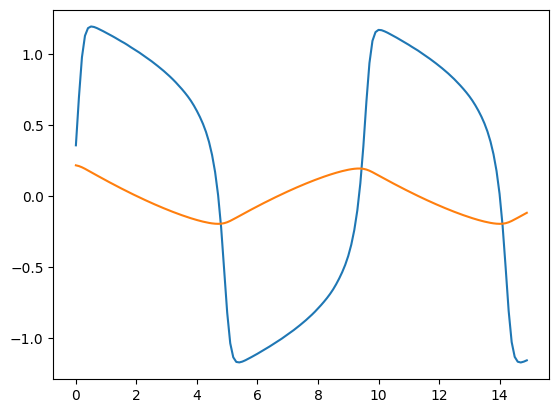

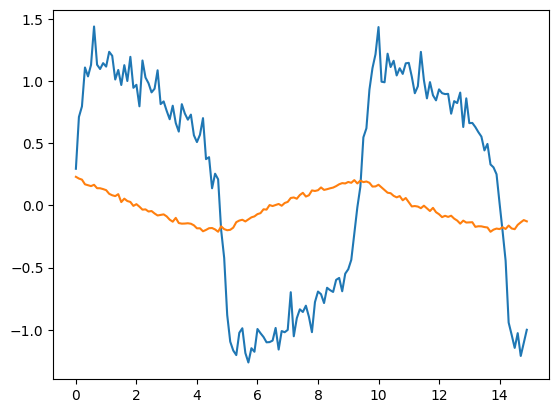

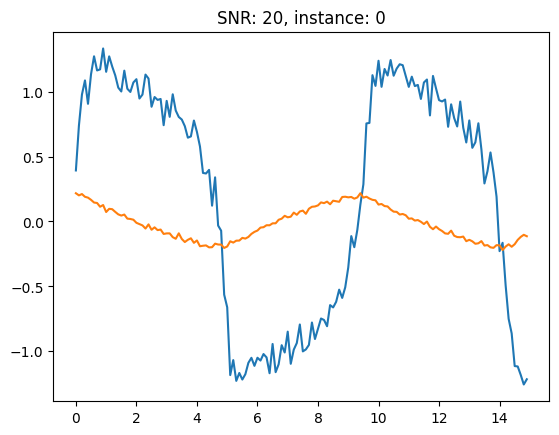

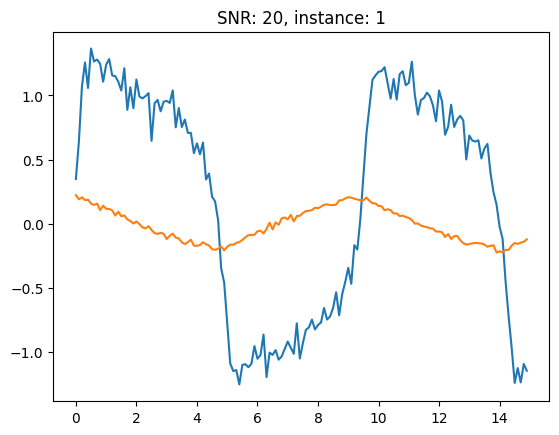

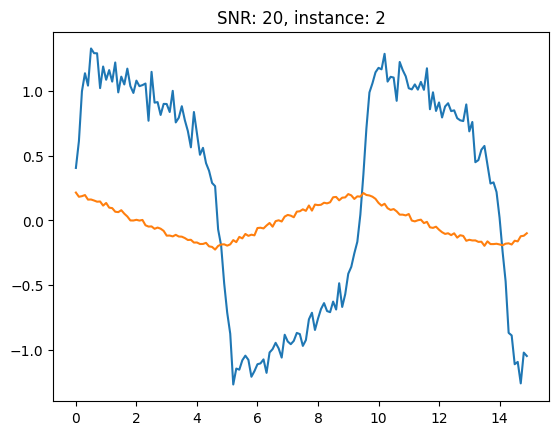

In [11]:
def dx(x,y):
    return 10. * (y - (x*x*x - x)/3.)
def dy(x,y):
    return -x/10.

h=0.1
t= np.arange(0,15,h)

def ode(t,y):
    return [dx(*y),dy(*y)]
sol=scipy.integrate.solve_ivp(ode, [t[0],t[-1]], y0=[0.3573,0.2166979], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]
    
print(len(t))
plt.plot(t,t_x)
plt.plot(t,t_y)
plt.show()
t_x_n=t_x + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_x), size=len(t_x))
t_y_n=t_y + 10 ** (-SNR/20) * np.random.normal(scale=np.std(t_y), size=len(t_x))

plt.plot(t,t_x_n)
plt.plot(t,t_y_n)
plt.show()

save_SNR_instance('vd_pol',SNR,t_x,t_y)